In [5]:
from src.state import InputState, Context
from src.graph.workflow import build_graph
from IPython.display import Image, display

from dotenv import load_dotenv

load_dotenv()

c:\Users\moism\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

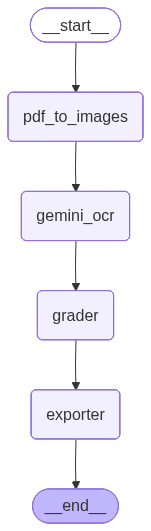

In [6]:
graph = build_graph(
        model="gpt-5",
        temperature=0.0,
    )

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
final_state = graph.invoke(
	input=InputState({
		"student_id": "student_02",
		"dpi": 300,
		"max_pages": 10,
		"exam_file": "Exam Java alternative 2025.txt",
		"rubric_file": "java_criteria.txt",
	}),
	context=Context(),
    )

Converted 10 pages.
Extracted text from 10 pages.

Grading exam...
Grading completed.

Exporting results...
Results exported.


In [8]:
print("\nFinal state:")
final_state.pop("messages")
for k, v in final_state.items():
	print(f"- {k}: {v}")


Final state:
- extract_dir: data\output\student_02\extracted_text
- export_dir: data\output\student_02\grading_results
- log_path: data\output\student_02\messages_log.log
- grader_result: Total Mark: 51.5

Evaluations:
	Question 1.1:
	Awarded Points: 1.5
	Justification: Partial. You wrote: "means that Java is a Langauge that works with diffirent components architectures". This suggests cross-architecture use, but you did not mention JVM/bytecode. Full credit requires stating that Java compiles to bytecode that runs on the JVM, making it hardware-agnostic.

	Question 1.2:
	Awarded Points: 0.0
	Justification: No answer provided. Your script shows only "2-" with nothing following. You needed to mention that the WWW/Internet enabled distributed, network-based programming and drove the need for platform-independent, secure, multithreaded languages like Java.

	Question 1.3:
	Awarded Points: 3.0
	Justification: Correct. You wrote: "POP emphisis on the procuders ... OOP emphysis on the class

In [9]:
from src.utils import io
import logging

logging.shutdown()

stream = graph.stream(
	input=InputState({
		"student_id": "student_03",
		"dpi": 300,
		"max_pages": 10,
		"exam_file": "Exam Java alternative 2025.txt",
		"rubric_file": "java_criteria.txt",
	}),
	context=Context(),
     stream_mode="updates",
     subgraphs=True,
     version="v2"
        )

for chunk in stream:
     if chunk["ns"]:
          node, values = list(chunk["data"].items())[0]
          print(f"\n- Subgraph[{node}] update\n  Messages:")
          for message in values.get("messages", []):
               message.content = io.truncate_text(message.content, limit=20)
               message.pretty_print()
     else:
          print(f"\n* Root[{list(chunk['data'].keys())[0]}] update\n" + "-" * 100)

Converted 10 pages.

* Root[pdf_to_images] update
----------------------------------------------------------------------------------------------------
Extracted text from 10 pages.

* Root[gemini_ocr] update
----------------------------------------------------------------------------------------------------

Grading exam...

- Subgraph[model] update
  Messages:
================================== Ai Message ==================================

{"total_mark":55.5,"evaluations":[{"question_id":"1.1","awarded_points":3,"justification":"Full credit. The answer captures architecture neutrality: \"java language is not ties on speciffe oprer operating system architecture\" (meaning not tied to specific OS/architecture)."},{"question_id":"1.2","awarded_points":1.5,"justification":"Partial. You wrote: \"as the w.w.w occur sharing dato become more wide... and can be accessed by any code\". Missing explicit mention of distributed/network-based programming and the motivation for platform-independent